# 06 Optimization Techniques

## 📚 Learning Objectives

By completing this notebook (~20 min), you will:
- Compare SGD and Adam optimizers on the same task (MNIST digits)
- See how the choice of optimizer affects loss curves and convergence
- Understand why we often use Adam instead of plain SGD

---

## 🌍 Real life

**Where is this used?** Every time you call `model.compile(optimizer='adam', ...)` or train a neural network, you choose an **optimizer** that uses the gradients from backprop to update the weights.

**In this notebook we use** **optimizers** (SGD and Adam) to **update the weights** so the network learns. We use **Adam** instead of plain **SGD** in many projects **because** Adam adapts the learning rate per parameter and usually **converges faster** and more reliably.

**📌 Covers slide(s):** Part of Unit 1 sequence (training flow). *Do after 05_backpropagation_detailed; then move to Unit 2.*

---

**Before starting:** Run the imports cell below. Requires TensorFlow.


## Theory (short)

- **Optimizer** = algorithm that uses gradients to update weights: `new_weight = old_weight - learning_rate * gradient` (or a variant).
- **SGD (Stochastic Gradient Descent):** uses the gradient directly; simple but can be slow and sensitive to learning rate.
- **Adam:** adapts a learning rate per parameter (momentum + scaling); usually converges faster and is less sensitive to the initial learning rate.
- **Data flow:** forward pass → loss → backprop (gradients) → **optimizer** updates weights → repeat.


## 📥 Inputs & 📤 Outputs

**Inputs:** MNIST (we use a subset of 10k training samples), TensorFlow/Keras, NumPy, Matplotlib. We build two identical small models in the notebook and train one with SGD and one with Adam.

**Dataset:** Real — MNIST (subset for SGD vs Adam comparison).

**Outputs:** Printed training loss and accuracy per epoch for SGD, then for Adam; then one plot with two curves (SGD train loss vs Adam train loss). Adam typically reaches lower loss in the same number of epochs.


In [1]:
# Step 1: Imports (run this first)
import numpy as np
import matplotlib.pyplot as plt

try:
    import tensorflow as tf
    print(f"TensorFlow {tf.__version__}")
    print("✅ Imports OK")
except Exception as e:
    err = str(e).lower()
    if "charset_normalizer" in err or "md__mypyc" in err or "partially initialized" in err:
        print("⚠️ TensorFlow failed: broken charset_normalizer. Fix: pip install --upgrade charset-normalizer requests, then restart kernel.")
        raise RuntimeError("Fix: pip install --upgrade charset-normalizer requests, then restart kernel.") from e
    print("⚠️ TensorFlow failed:", e)
    raise

TensorFlow 2.13.0
✅ Imports OK


In [2]:
# Step 2: Load MNIST and preprocess (small subset so it runs in ~5 min)
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0
x_train = x_train.reshape(-1, 784)
x_test = x_test.reshape(-1, 784)

# Use a subset so training is fast (we use 2 epochs per optimizer)
n_subset = 10000
x_train = x_train[:n_subset]
y_train = y_train[:n_subset]

print("Training samples:", x_train.shape[0])
print("We use 2 epochs per optimizer so the notebook runs in ~10 min.")

Training samples: 10000
We use 2 epochs per optimizer so the notebook runs in ~10 min.


In [3]:
# Step 3: Build a small model (we'll use the same architecture twice with different optimizers)
def make_model():
    return tf.keras.Sequential([
        tf.keras.layers.Dense(128, activation="relu", input_shape=(784,)),
        tf.keras.layers.Dense(10, activation="softmax"),
    ])

model_sgd = make_model()
model_adam = make_model()
print("Two identical models created (SGD and Adam).")

Two identical models created (SGD and Adam).


In [4]:
# Step 4: Train with SGD — we use SGD here to compare; in many projects we use Adam instead
# because Adam adapts the learning rate and usually converges faster.
model_sgd.compile(
    optimizer=tf.keras.optimizers.SGD(learning_rate=0.01),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

history_sgd = model_sgd.fit(
    x_train, y_train,
    epochs=2,
    batch_size=128,
    validation_split=0.1,
    verbose=1,
)

print("\nAfter this cell you should see: loss going down. SGD is simple but can be slower than Adam.")

Epoch 1/2



 1/71 [..............................] - ETA: 4s - loss: 2.4029 - accuracy: 0.0781


71/71 [==============================] - 0s 1ms/step - loss: 2.0806 - accuracy: 0.3260 - val_loss: 1.8228 - val_accuracy: 0.5740


Epoch 2/2



 1/71 [..............................] - ETA: 0s - loss: 1.8072 - accuracy: 0.5938


71/71 [==============================] - 0s 623us/step - loss: 1.5946 - accuracy: 0.6632 - val_loss: 1.3921 - val_accuracy: 0.7300



After this cell you should see: loss going down. SGD is simple but can be slower than Adam.


In [5]:
# Step 5: Train with Adam (same architecture, same data)
model_adam.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

history_adam = model_adam.fit(
    x_train, y_train,
    epochs=2,
    batch_size=128,
    validation_split=0.1,
    verbose=1,
)

print("\nAfter this cell you should see: loss going down. Adam often reaches lower loss in the same number of epochs.")

Epoch 1/2



 1/71 [..............................] - ETA: 4s - loss: 2.3766 - accuracy: 0.1016


71/71 [==============================] - 0s 1ms/step - loss: 0.8359 - accuracy: 0.7832 - val_loss: 0.3918 - val_accuracy: 0.8910


Epoch 2/2



 1/71 [..............................] - ETA: 0s - loss: 0.3125 - accuracy: 0.8828


71/71 [==============================] - 0s 651us/step - loss: 0.3367 - accuracy: 0.9083 - val_loss: 0.3020 - val_accuracy: 0.9130



After this cell you should see: loss going down. Adam often reaches lower loss in the same number of epochs.


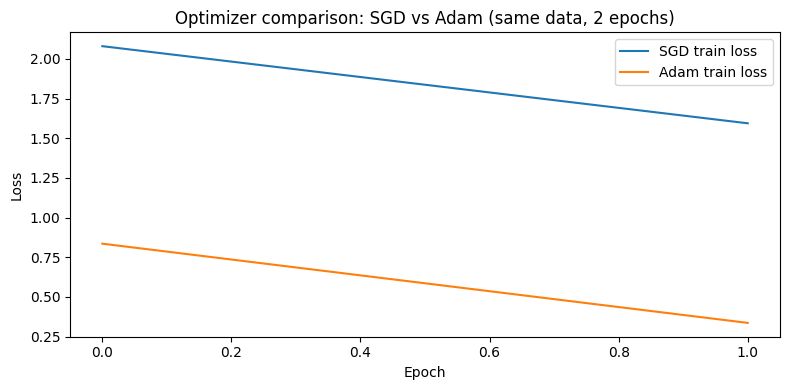

If Adam curve is below SGD, Adam converged faster. In real projects we often use Adam by default.


In [6]:
# Step 6: Plot loss comparison — SGD vs Adam
plt.figure(figsize=(8, 4))
plt.plot(history_sgd.history["loss"], label="SGD train loss", color="C0")
plt.plot(history_adam.history["loss"], label="Adam train loss", color="C1")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Optimizer comparison: SGD vs Adam (same data, 2 epochs)")
plt.legend()
plt.tight_layout()
plt.show()

print("If Adam curve is below SGD, Adam converged faster. In real projects we often use Adam by default.")

---

## 🧩 Mini-exercise

**Try it (choose one):** Train a third model with **RMSprop** (same architecture, 2 epochs) and add its loss curve to the plot. Compare SGD, Adam, and RMSprop. Or change the learning rate for SGD (e.g. 0.1 or 0.01) and see how the curve changes.

---

## ✅ Summary

**What you did:**
- Loaded MNIST subset and built two identical small models.
- Trained one with **SGD** and one with **Adam** for 2 epochs each.
- Plotted loss curves to compare; Adam often converges faster.

**In real life you'd also:** try different learning rates, use more epochs, and possibly try other optimizers (RMSprop, AdamW).

**The main idea:** The optimizer uses gradients from backprop to update weights; Adam adapts the step size per parameter and is often a good default.

**Next:** Unit 2 CNNs: e.g. `unit2-cnns/examples/01_cnn_architecture.ipynb`. Optionally, `07_image_processing_feature_extraction` (Unit 1) covers image basics before CNNs.
